In [57]:
import os
import json
import torch
import pandas as pd
import logging
import importlib
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
import importlib

import sys
PROJECT_DIR = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER"
SRC_DIR = str(Path(PROJECT_DIR) / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

# Testing how the data prep and caching interacts with the experiment_loader class

## Load a Saved TrainingDataFormatter Object

We can load a TDF object from the disk using the `load_tdf()` function. This recreates the TDF object from a cached `settings.json` file in the experiment's processed data directory. Other attributes such as the `genes`, `tf_names`, `tg_names`, and `peaks` are loaded from the saved files in the directory. Once the TDF object is loaded, we can verify that all of the necessary files are cached properly using the `create_or_load_data_cache()` method. 

> Note: The `create_or_load_data_cache()` method is also a nice shortcut for running all of the steps to create the cached data files

In [58]:
importlib.reload(experiment_handler)

experiment_name = "Macrophage_buffer_2_raw_muon_preprocessing"

tdf = data_formatter.load_tdf(
    settings_path = Path(PROJECT_DIR) / "data" / "processed" / experiment_name / "settings.json"
)

# Verify that the data cache files exist. If not, this method will create them.
tdf.create_or_load_data_cache(sample_name=tdf.sample_names[0], force_recalculate=False)

Loaded existing settings from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/Macrophage_buffer_2_raw_muon_preprocessing/settings.json
All required files are present.
Skipping data cache creation.


## Create an ExperimentHandler

The `ExperimentHander` class uses the files and attributes from the TDF object to manage model training, gradient attribution calculations, evaluation metric calculations, and plotting. The outputs from the `ExperimentHandler` class are saved to the `experiment_dir` attribute under numbered subdirectories that separate different experiments. This allows for multiple models to be trained per experiment without overwriting the results from previous trainings.

In [64]:
# The ExperimentHandler is a higher level class that handles the training and evaluation of the model.
# It takes in a TrainingDataFormatter object to handle file paths, data loading, and caching.
logging.info("Initializing ExperimentHandler...")
exp = experiment_handler.ExperimentHandler(
    training_data_formatter=tdf,
    experiment_dir="/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/experiments/",
    model_num=1,
    silence_warnings=False,
)

Initializing ExperimentHandler...


## Create the model training loaders

Once the `ExperimentHander` is loaded, we will load in the dataset we created in Step 020 and use it to make train/val/test dataloaders for model training and evaluation.

### Creating a Multichromosome Dataset

In [ ]:
# Creates a MultiChromosomeDataset dataset class, which handles loading data for one chromosome
# at a time and caching it in memory. The max_cached argument controls how many chromosomes worth 
# of data can be cached in memory at once. Each batch only contains TG and window data from one chromosome.
# The chromosomes are loaded sequentially, starting with the first chromosome in the chrom_list.
logging.info("Creating dataset...")
exp.create_multichrom_dataset(max_cached=100)

### Preparing the Train/Val/Test DataLoaders

In [ ]:
# Prepares the Train/Val/Test dataloaders, being careful to balance the number of 
# batches from each chromosome in each set.
logging.info("Preparing DataLoader...")
train_loader, val_loader, test_loader = exp.prepare_dataloader(
    batch_size=64,
    num_workers=8
)

### Creating Data Scalers

In [ ]:
# Creates scalers for the RNA and ATAC data based on the training split.
logging.info("Creating scalers...")
exp.create_scalers(train_loader)

## MultiomicTransformer model training

In [65]:


# Creates a new MultiomicTransformer model. Model attributes can be set to change
# the hyperparameters of the model.
logging.info("Creating model")
# exp.create_new_model()

exp.load_model()

# Runs model training and returns the trained model.
# logging.info("Training model")
# model = exp.train(
#     train_loader=train_loader, 
#     val_loader=val_loader, 
#     num_epochs=500,
#     max_batches=None,
#     save_every_n_epochs=10,
#     monitor_gpu_memory=True,
#     profile_batches=True,
#     allow_overwrite=True,
#     silence_tqdm=True,
#     )

# # Runs gradient attribution to calculate the gradients between each TF input and each TG output.
# logging.info("\nRunning Gradient Attribution")
# exp.run_gradient_attribution(
#     test_loader,
#     max_batches=None,
#     max_tgs_per_batch=None,
#     )

exp.grn = exp.load_grn()

# Loads a ground truth file with columns "Source" and "Target" for TF-TG interactions.
logging.info("Loading ground truth datasets...")
GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"
gt_by_dataset_dict = {
    "ChIP-Atlas macrophage": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
}

# Calculates the AUROC of the predicted GRN against multiple ground truth datasets.
logging.info("\nCalculating AUROC")
auroc_df = exp.calculate_auroc_all_sample_gts(exp.grn, gt_by_dataset_dict)     
logging.info(f"Pooled Median AUROC: {auroc_df['pooled_median_auroc'].iloc[0]:.3f}")       
logging.info(f"Per-TF Median AUROC: {auroc_df['per_tf_median_auroc'].iloc[0]:.3f}")

exp.save_handler()

Creating model
Loading ground truth datasets...

Calculating AUROC
Pooled Median AUROC: 0.515
Per-TF Median AUROC: 0.525


In [ ]:
from multiomic_transformer.utils import auroc_refactored
importlib.reload(auroc_refactored)

<module 'multiomic_transformer.utils.auroc_refactored' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/auroc_refactored.py'>

In [101]:
linger_grn_dir = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns/LINGER_muon")
scenic_grn_dir = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns/SCENIC_muon")

def print_grn_stats(grn_dir, method):
    logging.info(f"\n{method} GRN stats:")
    for file in grn_dir.glob("*.tsv"):
        method_name = file.stem
        method_name = method_name.replace(method, "")
        cell_type = method_name.split("_")[0]
        sample_name = "_".join(method_name.split("_")[1:])
        
        grn_df = pd.read_csv(file, sep="\t")
        n_tfs = grn_df["Source"].nunique()
        n_tgs = grn_df["Target"].nunique()
        n_edges = len(grn_df)
        logging.info(f"  - {cell_type} {sample_name}: {n_tfs:,} TFs, {n_tgs:,} TGs, {n_edges:,} edges")

print_grn_stats(scenic_grn_dir, "scenic_plus")
print_grn_stats(linger_grn_dir, "linger")


scenic_plus GRN stats:
  -  Macrophage_buffer_2: 70 TFs, 6,311 TGs, 66,400 edges
  -  mESC_E8.5_rep2: 145 TFs, 5,271 TGs, 80,969 edges
  -  K562_sample_1: 60 TFs, 6,719 TGs, 82,938 edges
  -  mESC_E7.5_rep2: 37 TFs, 3,102 TGs, 23,777 edges
  -  mESC_E8.5_rep1: 107 TFs, 4,025 TGs, 50,843 edges
  -  mESC_E7.5_rep1: 71 TFs, 3,648 TGs, 39,330 edges
  -  iPSC_WT_D13_rep1: 139 TFs, 3,411 TGs, 49,439 edges
  -  Macrophage_buffer_4: 85 TFs, 6,914 TGs, 74,651 edges
  -  Macrophage_buffer_1: 84 TFs, 6,365 TGs, 58,169 edges
  -  Macrophage_buffer_3: 73 TFs, 7,018 TGs, 84,706 edges

linger GRN stats:
  -  Macrophage_buffer_1: 395 TFs, 13,353 TGs, 5,274,435 edges
  -  mESC_E8.5_rep1: 646 TFs, 20,060 TGs, 12,958,760 edges
  -  mESC_E7.5_rep2: 574 TFs, 17,282 TGs, 9,919,868 edges
  -  mESC_E7.5_rep1: 632 TFs, 20,459 TGs, 12,930,088 edges
  -  K562_sample_1: 460 TFs, 15,290 TGs, 7,033,400 edges
  -  mESC_E8.5_rep2: 676 TFs, 22,283 TGs, 15,063,308 edges
  -  iPSC_WT_D13_rep1: 488 TFs, 17,084 TGs, 8,33

In [85]:
linger_grn_dir = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns/LINGER_muon")

for grn_file in linger_grn_dir.glob("*.tsv"):
    logging.info(f"Loading LINGER GRN file: {grn_file.name}")

    df = pd.read_csv(grn_file, sep="\t", index_col=0).reset_index()

    cols = set(df.columns)

    # Case 1: already long
    if {"Source", "Target", "Score"}.issubset(cols):
        
        if df["Source"].nunique() > df["Target"].nunique():
            logging.info(f"  - Renaming columns for {grn_file.name}")
            df = df.rename(columns={"Source": "Target", "Target": "Source"})
            df = df[["Source", "Target", "Score"]]
            df.to_csv(grn_file, sep="\t", index=False)
        else:
            logging.info(f"  - {grn_file.name} already appears to be in long format. Skipping.")
        
        continue

    # Case 2: likely wide
    source_col = df.columns[0]

    # Heuristic: wide GRN matrix usually has many columns beyond the first identifier column
    if len(df.columns) > 3:
        df_long = (
            df.melt(
                id_vars=source_col,
                var_name="Target",
                value_name="Score"
            )
            .rename(columns={source_col: "Source"})
        )

        # Optional: remove missing values
        df_long = df_long.dropna(subset=["Score"])

        out_file = grn_file.with_name(grn_file.stem + "_long.tsv")
        df_long.to_csv(out_file, sep="\t", index=False)
        logging.info(f"  - Saved melted GRN to {out_file.name}")
    else:
        logging.warning(f"  - Could not confidently determine format for {grn_file.name}. Skipping.")

Loading LINGER GRN file: linger_Macrophage_buffer_1.tsv
Renaming columns for linger_Macrophage_buffer_1.tsv
Loading LINGER GRN file: linger_mESC_E8.5_rep1.tsv
Renaming columns for linger_mESC_E8.5_rep1.tsv
Loading LINGER GRN file: linger_mESC_E7.5_rep2.tsv
Renaming columns for linger_mESC_E7.5_rep2.tsv
Loading LINGER GRN file: linger_mESC_E7.5_rep1.tsv
Renaming columns for linger_mESC_E7.5_rep1.tsv
Loading LINGER GRN file: linger_K562_sample_1.tsv
Renaming columns for linger_K562_sample_1.tsv
Loading LINGER GRN file: linger_mESC_E8.5_rep2.tsv
Renaming columns for linger_mESC_E8.5_rep2.tsv
Loading LINGER GRN file: linger_iPSC_WT_D13_rep1.tsv
Renaming columns for linger_iPSC_WT_D13_rep1.tsv
Loading LINGER GRN file: linger_Macrophage_buffer_3.tsv
Renaming columns for linger_Macrophage_buffer_3.tsv
Loading LINGER GRN file: linger_Macrophage_buffer_2.tsv
Renaming columns for linger_Macrophage_buffer_2.tsv
Loading LINGER GRN file: linger_Macrophage_buffer_4.tsv
Renaming columns for linger_Ma

In [63]:
importlib.reload(experiment_handler)

<module 'multiomic_transformer.utils.experiment_handler' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/experiment_handler.py'>

In [66]:
exp.calculate_auroc_all_methods(
    exp.tdf.sample_names, 
    "macrophage", 
    gt_by_dataset_dict, 
    grn=exp.grn,
    use_muon_grn=False
    )


Processing sample: buffer_2 | Dataset: macrophage
  - Loading CellOracle
  - Loading SCENIC+
  - Loading Pando
  - Loading LINGER
  - Loading FigR
  - Loading TRIPOD
  - Loading GRaNIE

Evaluating pooled methods across samples
  - Evaluating CellOracle
  - Evaluating SCENIC+
  - Evaluating Pando
  - Evaluating LINGER
  - Evaluating FigR
  - Evaluating TRIPOD
  - Evaluating GRaNIE
  - Evaluating Gradient Attribution
method
CellOracle              0.573769
SCENIC+                 0.563453
TRIPOD                  0.539404
FigR                    0.530576
LINGER                  0.522371
Gradient Attribution    0.515261
Pando                   0.496528
GRaNIE                  0.469467
Name: auroc, dtype: float64

Per-TF evaluation of pooled methods across samples
  - Per-TF evaluating CellOracle
  - Per-TF evaluating SCENIC+
  - Per-TF evaluating Pando
  - Per-TF evaluating LINGER
  - Per-TF evaluating FigR
  - Per-TF evaluating TRIPOD
  - Per-TF evaluating GRaNIE
  - Per-TF evaluating Gr

In [ ]:
importlib.reload(experiment_handler)

<module 'multiomic_transformer.utils.experiment_handler' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/experiment_handler.py'>


--- Model Training Summary ---
Final R2 (unscaled): 0.3762
Final R2 (scaled): 0.7698
Average Epoch Time: 6.95 seconds
Number of Metacells: 832
Number of Windows: 57,950


----- GRN Size -----
Number of unique TFs: 1,153
Number of unique TGs: 11,886
Number of edges: 13,704,558

----- AUROC -----
Median Pooled AUROC: 0.515
Median Per-TF AUROC: 0.523


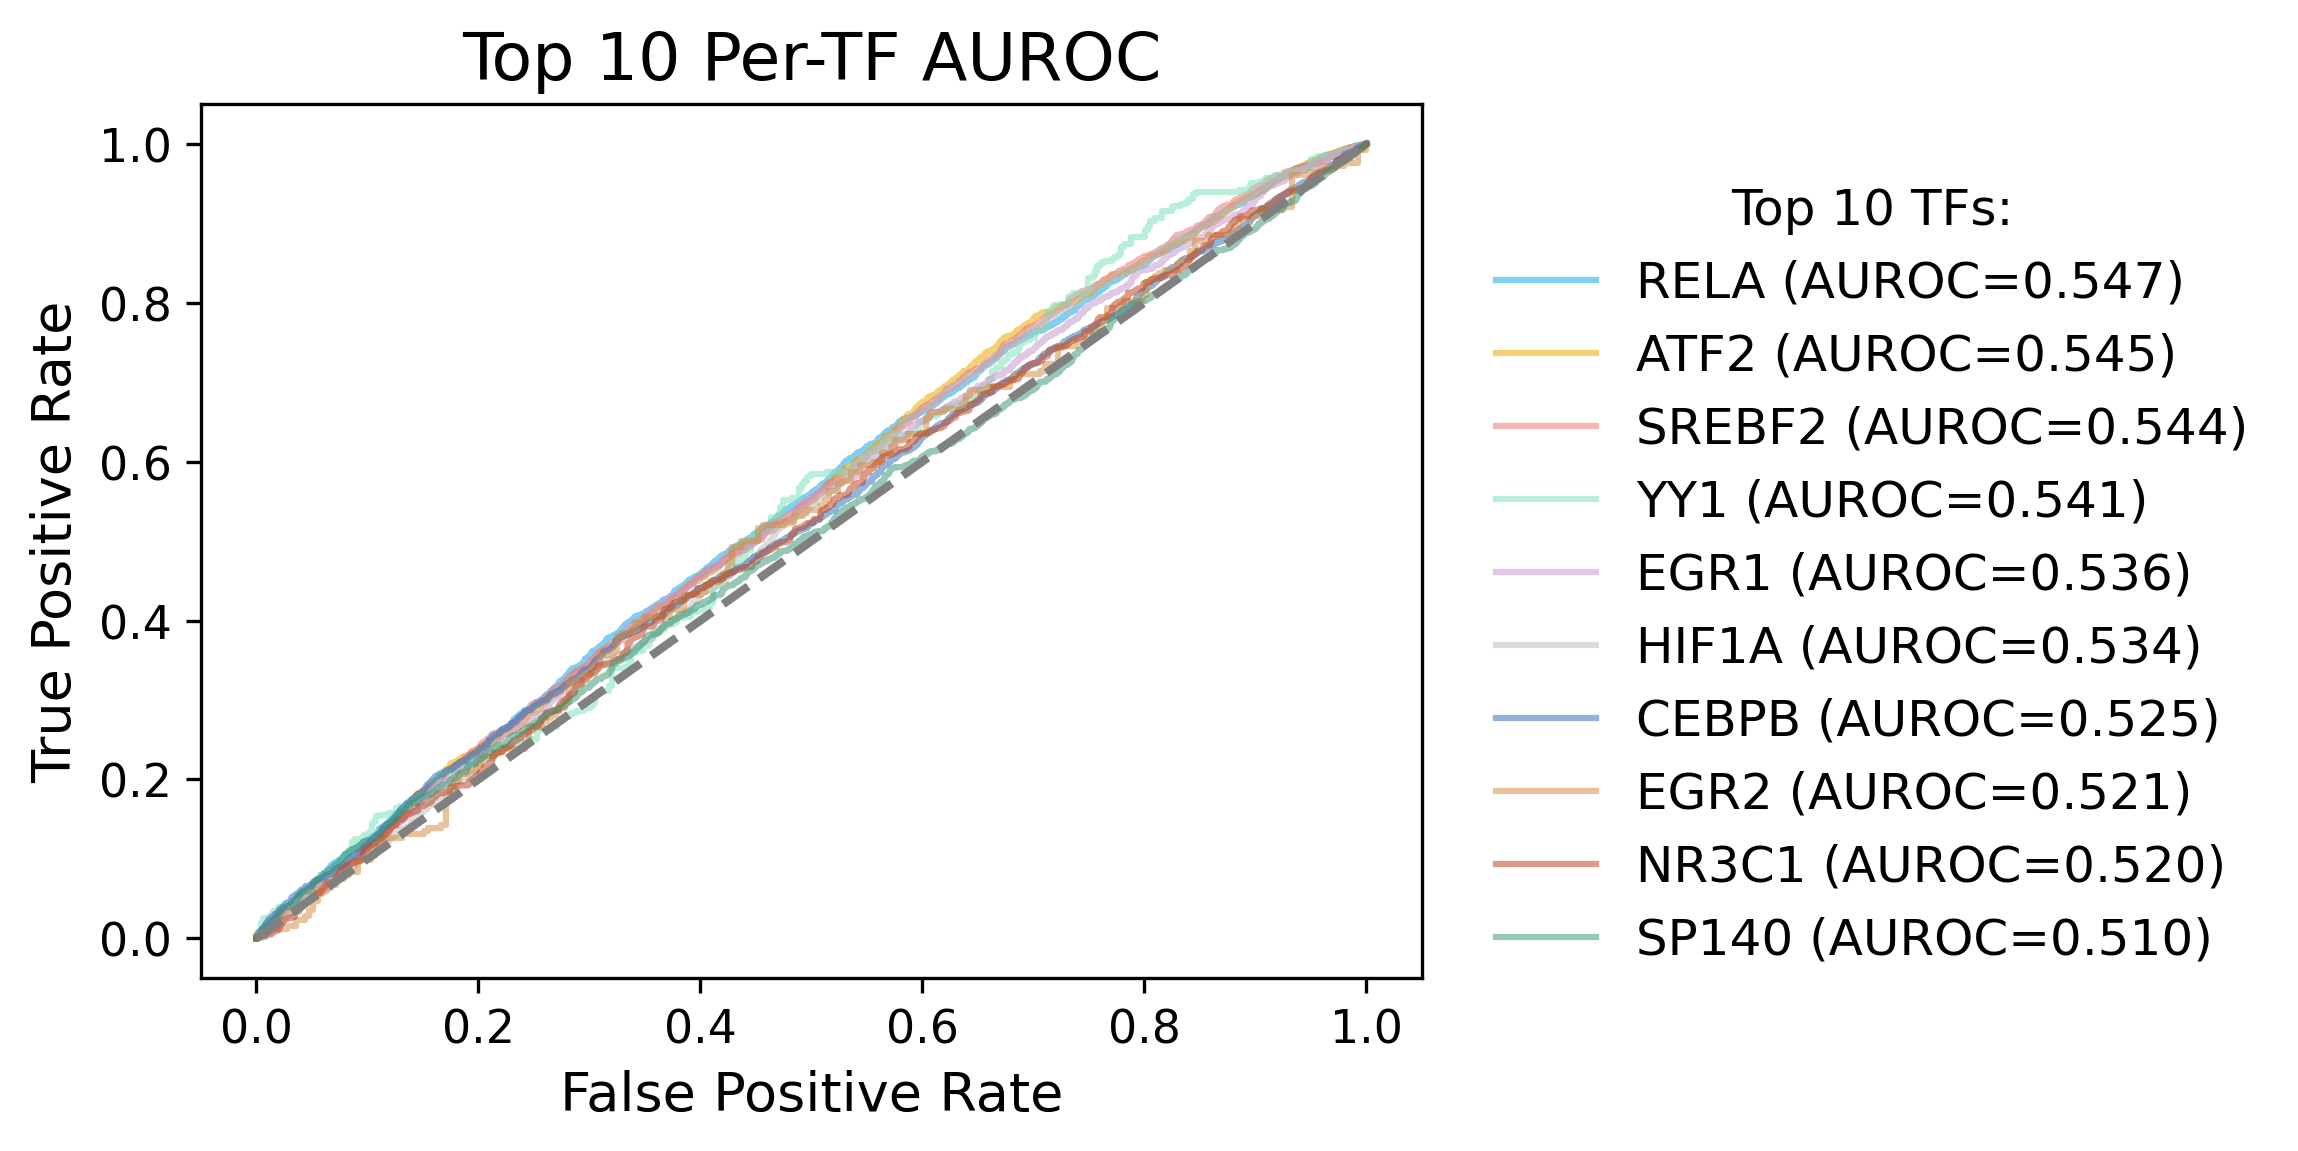

In [ ]:
ground_truth_name = "ChIP-Atlas macrophage"

exp.epoch_log_df.iloc[-1]
final_r2u = exp.epoch_log_df.iloc[-1]["r2_unscaled"]
final_r2s = exp.epoch_log_df.iloc[-1]["r2_scaled"]
avg_epoch_time = exp.epoch_log_df["epoch_time_s"].mean()

logging.info(f"\n--- Model Training Summary ---")
logging.info(f"Final R2 (unscaled): {final_r2u:.4f}")
logging.info(f"Final R2 (scaled): {final_r2s:.4f}")
logging.info(f"Average Epoch Time: {avg_epoch_time:.2f} seconds")
logging.info(f"Number of Metacells: {exp.tdf.num_metacells:,}")
logging.info(f"Number of Windows: {exp.tdf.num_windows:,}\n")

num_edges = len(exp.grn)
num_tfs = exp.grn["Source"].nunique()
num_tgs = exp.grn["Target"].nunique()

logging.info(f"\n----- GRN Size -----")
logging.info(f"Number of unique TFs: {num_tfs:,}")
logging.info(f"Number of unique TGs: {num_tgs:,}")
logging.info(f"Number of edges: {num_edges:,}")

# exp.report_grn_overlap_with_gt(ground_truth_name, gt_by_dataset_dict)

logging.info(f"\n----- AUROC -----")
per_tf_df_all =  pd.read_csv(exp.model_training_dir / "per_tf_auroc_auprc_results.csv")
pooled_df_all = pd.read_csv(exp.model_training_dir / "pooled_auroc_auprc_results.csv")

per_tf_plot_df = (
    per_tf_df_all.dropna(subset=["auroc"])
    .groupby(['method', 'gt'], as_index=False)
    .agg(
        auroc=('auroc', 'median'),
    )
)

pooled_df_median_auroc = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]["auroc"].median()
per_tf_median_auroc = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]["auroc"].median()

logging.info(f"Median Pooled AUROC: {pooled_df_median_auroc:.3f}")
logging.info(f"Median Per-TF AUROC: {per_tf_median_auroc:.3f}")

fig_dir = exp.model_training_dir / "figures"
fig_dir.mkdir(exist_ok=True)

name = exp.experiment_name.replace("_", " ")
per_tf_plot, per_tf_df, tf_curves = exp.plot_top_n_tf_roc_curves(
    exp.grn, 
    gt_by_dataset_dict[ground_truth_name], 
    ground_truth_name, 
    exp, 
    method_name="Gradient Attribution", 
    num_top_tfs_to_plot=10,
    min_edges=500,
    min_pos=50,
    balance=True,
    name_clean=name,
    override_title=f"Top 10 Per-TF AUROC"
    )
per_tf_plot.show()
# per_tf_plot.savefig(fig_dir / f"top_10_per_tf_auroc.png", dpi=250)
# plt.close(per_tf_plot)

# pooled_auroc_boxplot_fig = exp._plot_all_results_auroc_boxplot(
#     pooled_df_all,
#     per_tf=False,
#     ylim=(0.2, 0.8),
#     override_title=f"Pooled AUROC per Method",
#     method_color_dict=exp.method_color_dict
# )
# pooled_auroc_boxplot_fig.savefig(fig_dir / f"pooled_auroc_boxplot.png", dpi=250)
# plt.close(pooled_auroc_boxplot_fig)

# per_tf_auroc_boxplot_fig = exp._plot_all_results_auroc_boxplot(
#     per_tf_plot_df, 
#     per_tf=True,
#     ylim=(0.2, 0.8),
#     override_title=f"Per-TF AUROC per Method",
#     method_color_dict=exp.method_color_dict
#     )
# per_tf_auroc_boxplot_fig.savefig(fig_dir / f"per_tf_auroc_boxplot.png", dpi=250)
# plt.close(per_tf_auroc_boxplot_fig)

# relative_improvement_fig = exp.plot_relative_improvement(
#     per_tf_plot_df, 
#     exp.experiment_name,
#     override_title=f"Per-TF AUROC Improvement",
#     )
# relative_improvement_fig.savefig(fig_dir / f"relative_improvement.png", dpi=250)
# plt.close(relative_improvement_fig)

# pooled_auroc_heatmap_fig = exp.plot_method_gt_heatmap(
#     pooled_df_all, 
#     per_tf=False,
#     x_scale=1.2,
#     y_scale=0.6,
#     override_title=f"Pooled AUROC by Method and GT"
#     )
# pooled_auroc_heatmap_fig.savefig(fig_dir / f"pooled_auroc_heatmap.png", dpi=250)
# plt.close(pooled_auroc_heatmap_fig)

# per_tf_auroc_heatmap_fig = exp.plot_method_gt_heatmap(
#     per_tf_plot_df, 
#     per_tf=True,
#     x_scale=1.2,
#     y_scale=0.6,
#     override_title=f"Per-TF AUROC by Method and GT"
#     )
# per_tf_auroc_heatmap_fig.savefig(fig_dir / f"per_tf_auroc_heatmap.png", dpi=250)
# plt.close(per_tf_auroc_heatmap_fig)

# true_vs_predicted_fig = exp.plot_true_vs_predicted_tg_expression(
#     num_batches=50, 
#     set_axis_logscale=False,
#     title=f"Predicted vs True TG Expression"
#     )
# true_vs_predicted_fig.savefig(fig_dir / f"true_vs_predicted.png", dpi=250)
# plt.close(true_vs_predicted_fig)

# logging.info(f"\n----- Saving Experiment -----")
# exp.save_handler()
# logging.info(f"Experiment saved to {exp.experiment_dir}")

## Loading a saved ExperimentHandler

In [ ]:
importlib.reload(experiment_handler)
importlib.reload(data_formatter)

<module 'multiomic_transformer.utils.data_formatter' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/src/multiomic_transformer/utils/data_formatter.py'>

In [103]:
GROUND_TRUTH_DIR = Path(PROJECT_DIR) / "data" / "ground_truth_files"
gt_by_dataset_dict = {
    "Macrophage": {
        # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
        "ChIP-Atlas macrophage": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
    },
    "mESC": {
        "ChIP-Atlas mESC": exp.load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": exp.load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": exp.load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": exp.load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": exp.load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    "K562": {
        "ChIP-Atlas K562": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
        "RN117": exp.load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    },
    "iPSC": {
        # "ChIP-Atlas iPSC": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
        "ChIP-Atlas iPSC (1 Mb)": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
        # "ChIP-Atlas iPSC (100 kb)": exp.load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    }
}

In [105]:
experiment_name = "mESC_E7.5_rep1_full_pipeline"
DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/PROCESSED_DATA")
exp = experiment_handler.load_experiment_handler(
    tdf_settings_path=DATA_DIR / experiment_name / "settings.json",
    experiment_dir=Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/"),
    model_num=2,
    )

gt_by_dataset_dict_sample = gt_by_dataset_dict["mESC"]

Loaded existing settings from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/PROCESSED_DATA/mESC_E7.5_rep1_full_pipeline/settings.json
Loading ExperimentHandler state from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/mESC_E7.5_rep1_full_pipeline/model_training_002/experiment_handler_save.json...


In [107]:
exp.calculate_auroc_all_methods(
    exp.tdf.sample_names, 
    "mESC", 
    gt_by_dataset_dict_sample, 
    grn=exp.grn,
    use_muon_grn=True
)


Processing sample: E7.5_rep1 | Dataset: mESC
  - Loading SCENIC+
  - Loading LINGER

Evaluating pooled methods across samples
  - Evaluating SCENIC+
  - Evaluating LINGER
  - Evaluating Gradient Attribution
method
SCENIC+                 0.587922
LINGER                  0.549797
Gradient Attribution    0.540568
Name: auroc, dtype: float64

Per-TF evaluation of pooled methods across samples
  - Per-TF evaluating SCENIC+
  - Per-TF evaluating LINGER
  - Per-TF evaluating Gradient Attribution
method
Gradient Attribution    0.546584
LINGER                  0.536276
SCENIC+                 0.491285
Name: median_per_tf_auroc, dtype: float64


In [108]:
logging.info(f"\n----- GRN Overlap with Ground Truth -----")
for ground_truth_name, ground_truth in gt_by_dataset_dict_sample.items():
    exp.report_grn_overlap_with_gt(ground_truth_name, ground_truth)

logging.info(f"\n----- AUROC -----")
per_tf_df_all =  pd.read_csv(exp.model_training_dir / "per_tf_auroc_auprc_results.csv")
pooled_df_all = pd.read_csv(exp.model_training_dir / "pooled_auroc_auprc_results.csv")

per_tf_plot_df = (
    per_tf_df_all.dropna(subset=["auroc"])
    .groupby(['method', 'gt'], as_index=False)
    .agg(
        auroc=('auroc', 'median'),
    )
)

pooled_df_median_auroc = pooled_df_all[pooled_df_all["method"] == "Gradient Attribution"]["auroc"].median()
per_tf_median_auroc = per_tf_plot_df[per_tf_plot_df["method"] == "Gradient Attribution"]["auroc"].median()

logging.info(f"Median Pooled AUROC: {pooled_df_median_auroc:.3f}")
logging.info(f"Median Per-TF AUROC: {per_tf_median_auroc:.3f}")

fig_dir = exp.model_training_dir / "figures"
fig_dir.mkdir(exist_ok=True)

ground_truth_name = "ChIP-Atlas mESC"

name = exp.experiment_name.replace("_", " ")
per_tf_plot, per_tf_df, tf_curves = exp.plot_top_n_tf_roc_curves(
    exp.grn, 
    gt_by_dataset_dict_sample[ground_truth_name], 
    ground_truth_name, 
    exp, 
    method_name="Gradient Attribution", 
    num_top_tfs_to_plot=10,
    min_edges=500,
    min_pos=50,
    balance=True,
    name_clean=name,
    override_title=f"Top 10 Per-TF AUROC"
    )
per_tf_plot.savefig(fig_dir / f"top_10_per_tf_auroc.png", dpi=250, bbox_inches="tight")
plt.close(per_tf_plot)

pooled_auroc_boxplot_fig = exp._plot_all_results_auroc_boxplot(
    pooled_df_all,
    per_tf=False,
    ylim=(0.2, 0.8),
    override_title=f"Pooled AUROC per Method",
    method_color_dict=exp.method_color_dict
)
pooled_auroc_boxplot_fig.savefig(fig_dir / f"pooled_auroc_boxplot.png", dpi=250, bbox_inches="tight")
plt.close(pooled_auroc_boxplot_fig)

per_tf_auroc_boxplot_fig = exp._plot_all_results_auroc_boxplot(
    per_tf_plot_df, 
    per_tf=True,
    ylim=(0.2, 0.8),
    override_title=f"Per-TF AUROC per Method",
    method_color_dict=exp.method_color_dict
    )
per_tf_auroc_boxplot_fig.savefig(fig_dir / f"per_tf_auroc_boxplot.png", dpi=250, bbox_inches="tight")
plt.close(per_tf_auroc_boxplot_fig)

relative_improvement_fig = exp.plot_relative_improvement(
    per_tf_plot_df, 
    exp.experiment_name,
    override_title=f"Per-TF AUROC Improvement",
    )
relative_improvement_fig.savefig(fig_dir / f"relative_improvement.png", dpi=250, bbox_inches="tight")
plt.close(relative_improvement_fig)

pooled_auroc_heatmap_fig = exp.plot_method_gt_heatmap(
    pooled_df_all, 
    per_tf=False,
    x_scale=1.2,
    y_scale=0.6,
    override_title=f"Pooled AUROC by Method and GT"
    )
pooled_auroc_heatmap_fig.savefig(fig_dir / f"pooled_auroc_heatmap.png", dpi=250, bbox_inches="tight")
plt.close(pooled_auroc_heatmap_fig)

per_tf_auroc_heatmap_fig = exp.plot_method_gt_heatmap(
    per_tf_plot_df, 
    per_tf=True,
    x_scale=1.2,
    y_scale=0.6,
    override_title=f"Per-TF AUROC by Method and GT"
    )
per_tf_auroc_heatmap_fig.savefig(fig_dir / f"per_tf_auroc_heatmap.png", dpi=250, bbox_inches="tight")
plt.close(per_tf_auroc_heatmap_fig)

true_vs_predicted_fig = exp.plot_true_vs_predicted_tg_expression(
    num_batches=50, 
    set_axis_logscale=False,
    title=f"Predicted vs True TG Expression"
    )
true_vs_predicted_fig.savefig(fig_dir / f"true_vs_predicted.png", dpi=250, bbox_inches="tight")
plt.close(true_vs_predicted_fig)


----- GRN Overlap with Ground Truth -----
ChIP-Atlas mESC
  - TF Overlap: 83 (131 in GT)
  - TG Overlap: 14,293 (24,821 in GT)
  - Edge Overlap: 1,186,319 (7,734,466 in GT)
RN111
  - TF Overlap: 80 (247 in GT)
  - TG Overlap: 13,051 (25,692 in GT)
  - Edge Overlap: 1,044,080 (972,636 in GT)
RN112
  - TF Overlap: 36 (55 in GT)
  - TG Overlap: 9,067 (16,522 in GT)
  - Edge Overlap: 326,412 (104,201 in GT)
RN114
  - TF Overlap: 30 (47 in GT)
  - TG Overlap: 10,728 (21,240 in GT)
  - Edge Overlap: 321,840 (107,980 in GT)
RN116
  - TF Overlap: 19 (21 in GT)
  - TG Overlap: 3,282 (4,542 in GT)
  - Edge Overlap: 62,358 (8,170 in GT)

----- AUROC -----
Median Pooled AUROC: 0.541
Median Per-TF AUROC: 0.547
Running forward pass to get predicted vs true TG expression for a subset of test batches...
Running forward pass: 100%|█████████████████████| 50/50 [00:00<00:00, 58.32it/s]


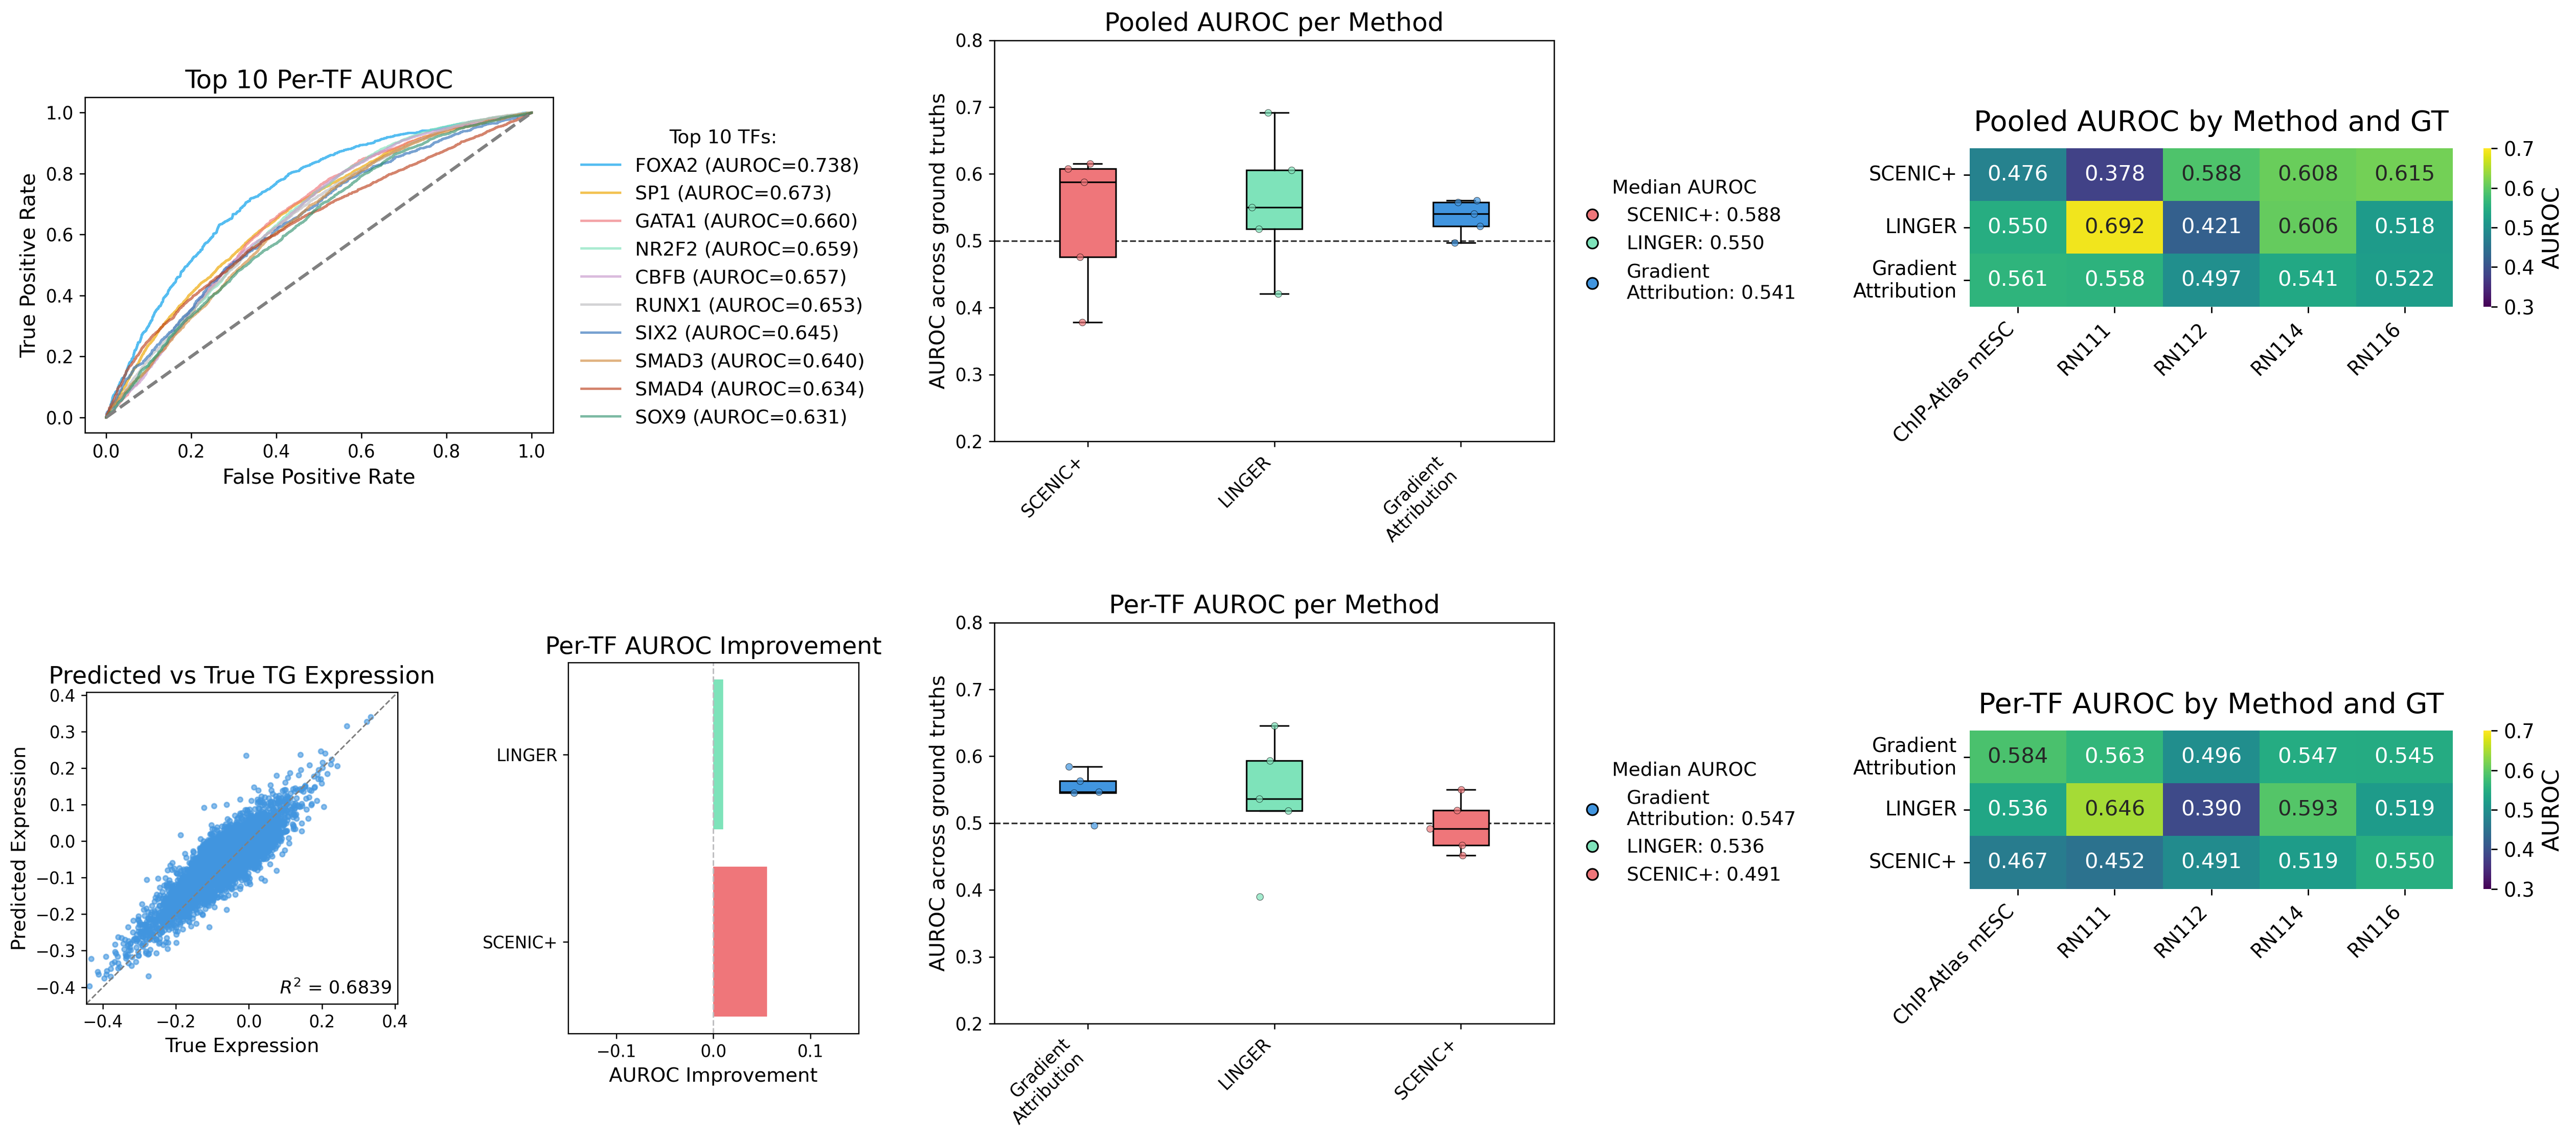

In [ ]:
from PIL import Image

def combine_images_with_spans(
    layout,
    space,
    fig_dir,
    output_name="combined_images.png",
    bg_color=(255, 255, 255, 255),
):
    """
    Combine images into a manually positioned grid with optional row/column spanning.

    Parameters
    ----------
    layout : dict
        Dictionary mapping image path -> config dict

        Required keys per image:
            row : int
            col : int

        Optional keys per image:
            scale : float, default 1.0
            rowspan : int, default 1
            colspan : int, default 1

        Example:
        {
            Path("a.png"): {"row": 0, "col": 0, "scale": 1.0, "rowspan": 1, "colspan": 2},
            Path("b.png"): {"row": 0, "col": 2, "scale": 0.8},
            Path("c.png"): {"row": 1, "col": 0, "scale": 1.1, "rowspan": 2, "colspan": 2},
        }

    space : int
        Pixels between grid cells.
    fig_dir : Path
        Output directory.
    output_name : str
        Output filename.
    bg_color : tuple
        RGBA background color.

    Returns
    -------
    Path
        Path to the saved combined image.
    """
    items = []

    # Load images and parse layout
    for image_path, cfg in layout.items():
        row = cfg["row"]
        col = cfg["col"]
        scale = cfg.get("scale", 1.0)
        rowspan = cfg.get("rowspan", 1)
        colspan = cfg.get("colspan", 1)

        if rowspan < 1 or colspan < 1:
            raise ValueError(f"{image_path}: rowspan and colspan must be >= 1")

        img = Image.open(image_path).convert("RGBA")
        new_width = max(1, int(img.width * scale))
        new_height = max(1, int(img.height * scale))
        img_resized = img.resize((new_width, new_height), Image.LANCZOS)

        items.append({
            "path": image_path,
            "row": row,
            "col": col,
            "rowspan": rowspan,
            "colspan": colspan,
            "img": img_resized,
            "width": new_width,
            "height": new_height,
        })

    if not items:
        raise ValueError("Layout is empty.")

    n_rows = max(item["row"] + item["rowspan"] for item in items)
    n_cols = max(item["col"] + item["colspan"] for item in items)

    # Check for overlapping occupied cells
    occupied = {}
    for item in items:
        for r in range(item["row"], item["row"] + item["rowspan"]):
            for c in range(item["col"], item["col"] + item["colspan"]):
                key = (r, c)
                if key in occupied:
                    raise ValueError(
                        f"Overlap detected: {item['path']} overlaps with {occupied[key]} at cell {key}"
                    )
                occupied[key] = item["path"]

    # Compute minimum column widths and row heights
    # Start from single-cell requirements
    col_widths = [0] * n_cols
    row_heights = [0] * n_rows

    for item in items:
        if item["colspan"] == 1:
            col_widths[item["col"]] = max(col_widths[item["col"]], item["width"])
        if item["rowspan"] == 1:
            row_heights[item["row"]] = max(row_heights[item["row"]], item["height"])

    # Expand widths/heights as needed for spanned items
    # A simple iterative pass is usually enough for plotting layouts
    for _ in range(10):
        changed = False

        for item in items:
            # Width across spanned columns, including inter-column spaces inside the span
            current_span_width = (
                sum(col_widths[item["col"]: item["col"] + item["colspan"]])
                + space * (item["colspan"] - 1)
            )
            if current_span_width < item["width"]:
                deficit = item["width"] - current_span_width
                add_per_col = deficit / item["colspan"]
                for c in range(item["col"], item["col"] + item["colspan"]):
                    new_val = int(round(col_widths[c] + add_per_col))
                    if new_val > col_widths[c]:
                        col_widths[c] = new_val
                        changed = True

            # Height across spanned rows, including inter-row spaces inside the span
            current_span_height = (
                sum(row_heights[item["row"]: item["row"] + item["rowspan"]])
                + space * (item["rowspan"] - 1)
            )
            if current_span_height < item["height"]:
                deficit = item["height"] - current_span_height
                add_per_row = deficit / item["rowspan"]
                for r in range(item["row"], item["row"] + item["rowspan"]):
                    new_val = int(round(row_heights[r] + add_per_row))
                    if new_val > row_heights[r]:
                        row_heights[r] = new_val
                        changed = True

        if not changed:
            break

    # Compute canvas size
    background_width = sum(col_widths) + space * (n_cols - 1)
    background_height = sum(row_heights) + space * (n_rows - 1)

    background = Image.new("RGBA", (background_width, background_height), bg_color)

    # Precompute grid start coordinates
    col_starts = []
    x = 0
    for w in col_widths:
        col_starts.append(x)
        x += w + space

    row_starts = []
    y = 0
    for h in row_heights:
        row_starts.append(y)
        y += h + space

    # Paste each image centered within its spanned rectangle
    for item in items:
        x0 = col_starts[item["col"]]
        y0 = row_starts[item["row"]]

        span_width = (
            sum(col_widths[item["col"]: item["col"] + item["colspan"]])
            + space * (item["colspan"] - 1)
        )
        span_height = (
            sum(row_heights[item["row"]: item["row"] + item["rowspan"]])
            + space * (item["rowspan"] - 1)
        )

        x_offset = (span_width - item["width"]) // 2
        y_offset = (span_height - item["height"]) // 2

        paste_x = x0 + x_offset
        paste_y = y0 + y_offset

        background.paste(item["img"], (paste_x, paste_y), item["img"])

    output_path = fig_dir / output_name
    background.save(output_path)
    return output_path

layout = {
    fig_dir / "top_10_per_tf_auroc.png": {
        "row": 0, "col": 0, "scale": 0.9, "rowspan": 1, "colspan": 2
    },
    fig_dir / "pooled_auroc_boxplot.png": {
        "row": 0, "col": 2, "scale": 0.9
    },
    fig_dir / "pooled_auroc_heatmap.png": {
        "row": 0, "col": 3, "scale": 1.0
    },
    fig_dir / "true_vs_predicted.png": {
        "row": 1, "col": 0, "scale": 0.85
    },
    fig_dir / "relative_improvement.png": {
        "row": 1, "col": 1, "scale": 0.85
    },
    fig_dir / "per_tf_auroc_boxplot.png": {
        "row": 1, "col": 2, "scale": 0.9
    },
    fig_dir / "per_tf_auroc_heatmap.png": {
        "row": 1, "col": 3, "scale": 1.0
    },
}

output_path = combine_images_with_spans(
    layout=layout,
    space=50,
    fig_dir=fig_dir,
    output_name="combined_images.png",
)

from IPython.display import Image
Image(str(output_path))